# Student Performance Predictor
## Machine Learning Subject Project

**Dataset:** UCI Student Performance Dataset (Portuguese Language Course)  
**Algorithm:** Logistic Regression (Multinomial)  
**Author:** [Zain Ullah]  
**Date:** June 2026

---

## Problem Statement
Predict a student's final grade (A/B/C/D/F) based on demographic,
social, and academic features collected from Portuguese high school students.

## Dataset Description
- 649 students, 33 features
- Source: Cortez & Silva, 2008 — University of Minho, Portugal
- Target variable: G3 (final grade, converted to letter grades)

## 1. Importing Libraries

In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

All libraries loaded ✓


In [2]:
import os

# List all available datasets
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/__results__.html
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/__resultx__.html
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/__notebook__.ipynb
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/__output__.json
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/custom.css
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/__results___files/__results___5_2.png
/kaggle/input/notebooks/ghayurhamza/portuguese-gradeprediction/__results___files/__results___6_0.png


## 2. Loading & Exploring the Dataset


In [3]:
# Cell 2 — Load the real UCI dataset
df = pd.read_csv('/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv', sep=',')


print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (649, 33)

Columns:
 ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 3 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12


In [4]:
print(df.columns.tolist())
print(df.head(2))


['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob     Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home  teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home    other  ...   

  famrel freetime  goout  Dalc  Walc health absences G1  G2  G3  
0      4        3      4     1     1      3        4  0  11  11  
1      5        3      3     1     1      3        2  9  11  11  

[2 rows x 33 columns]


## 3. Feature Engineering & Target Variable

In [5]:
# Cell 3 — Feature engineering & target variable
# G3 is the final grade (0–20). Convert to letter grades.
def grade_label(g3):
    if g3 >= 17: return 'A'
    elif g3 >= 14: return 'B'
    elif g3 >= 11: return 'C'
    elif g3 >= 8:  return 'D'
    else:          return 'F'

df['grade'] = df['G3'].apply(grade_label)

# Select meaningful features (drop G1, G2 to avoid data leakage)
features = ['age', 'studytime', 'failures', 'absences',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

# Encode binary categoricals
df['sex_enc']     = (df['sex'] == 'M').astype(int)
df['address_enc'] = (df['address'] == 'U').astype(int)
df['internet_enc']= (df['internet'] == 'yes').astype(int)
df['romantic_enc']= (df['romantic'] == 'yes').astype(int)

extra = ['sex_enc', 'address_enc', 'internet_enc', 'romantic_enc',
         'Medu', 'Fedu', 'traveltime', 'schoolsup_enc']

df['schoolsup_enc'] = (df['schoolsup'] == 'yes').astype(int)
all_features = features + extra

print("Grade distribution:")
print(df['grade'].value_counts().sort_index())
print(f"\nTotal features used: {len(all_features)}")

Grade distribution:
grade
A     46
B    148
C    258
D    167
F     30
Name: count, dtype: int64

Total features used: 18


## 4. Exploratory Data Analysis (EDA)

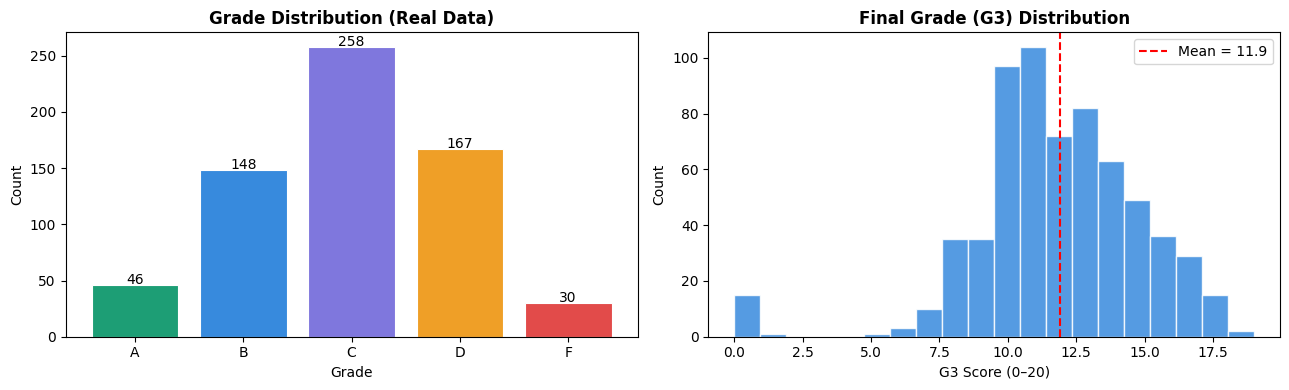

In [6]:
# Cell 4 — EDA: Grade distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grade counts
grade_order = ['A', 'B', 'C', 'D', 'F']
colors = ['#1D9E75','#378ADD','#7F77DD','#EF9F27','#E24B4A']
counts = [df['grade'].value_counts().get(g, 0) for g in grade_order]
axes[0].bar(grade_order, counts, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Grade Distribution (Real Data)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Grade'); axes[0].set_ylabel('Count')
for i, c in enumerate(counts):
    axes[0].text(i, c + 1, str(c), ha='center', fontsize=10)

# G3 score distribution
axes[1].hist(df['G3'], bins=20, color='#378ADD', alpha=0.85, edgecolor='white')
axes[1].set_title('Final Grade (G3) Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('G3 Score (0–20)'); axes[1].set_ylabel('Count')
axes[1].axvline(df['G3'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['G3'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Exploratory Data Analysis (EDA)

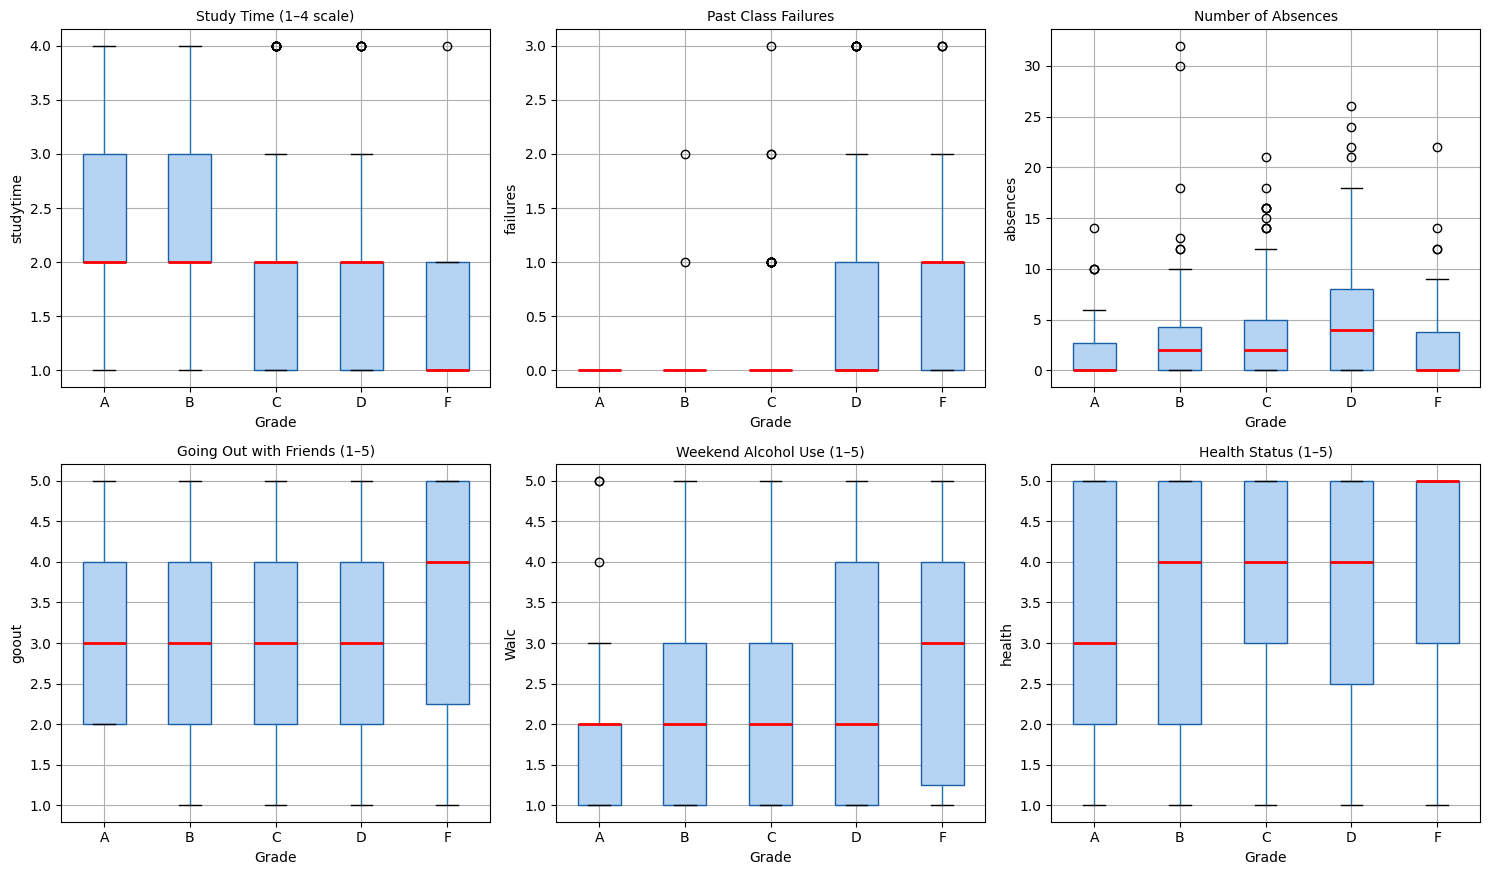

In [7]:
# Cell 5 — EDA: Key features vs final grade
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Key Features vs Final Grade (G3)', fontsize=13, fontweight='bold')

plot_features = [
    ('studytime',  'Study Time (1–4 scale)'),
    ('failures',   'Past Class Failures'),
    ('absences',   'Number of Absences'),
    ('goout',      'Going Out with Friends (1–5)'),
    ('Walc',       'Weekend Alcohol Use (1–5)'),
    ('health',     'Health Status (1–5)'),
]

for ax, (feat, title) in zip(axes.flatten(), plot_features):
    df.boxplot(column=feat, by='grade', ax=ax,
               positions=range(len(grade_order)),
               patch_artist=True,
               boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Grade'); ax.set_ylabel(feat)
    ax.set_xticklabels(grade_order)

plt.suptitle('')
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.Correlation Analysis

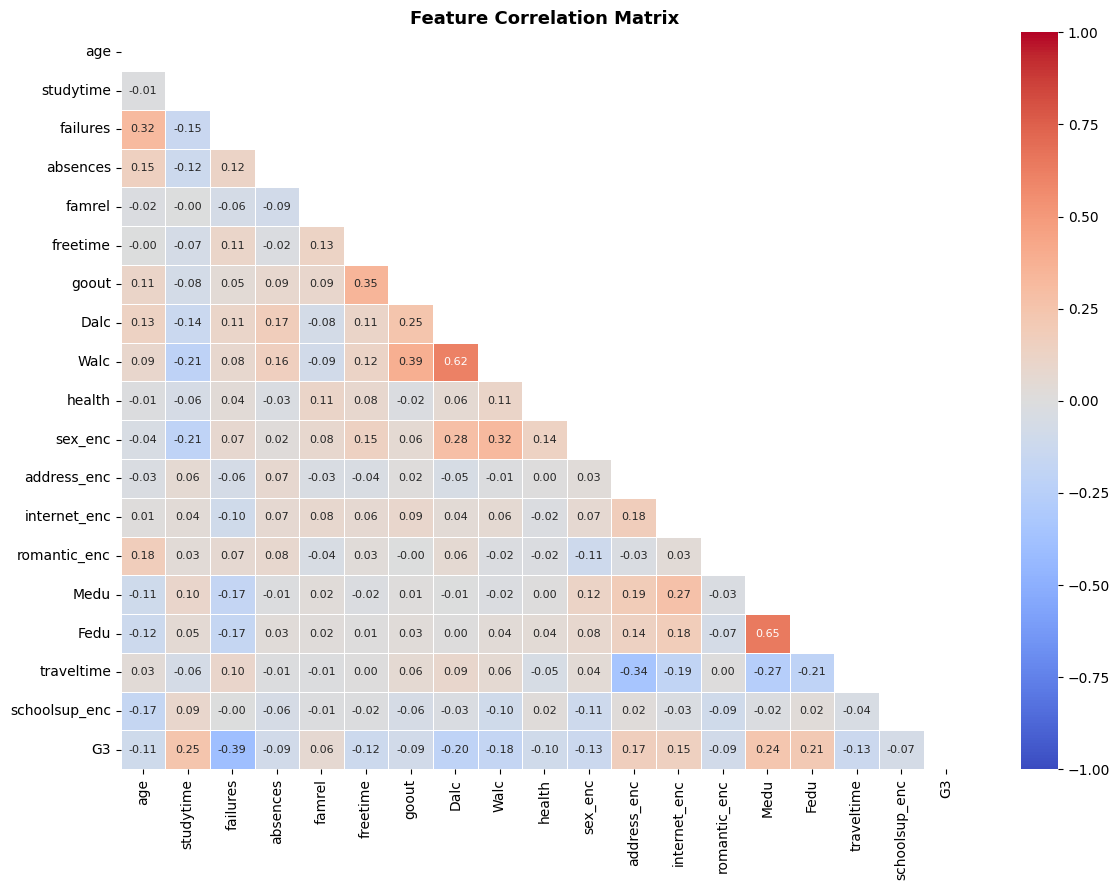

In [8]:
# Cell 6 — Correlation heatmap
plt.figure(figsize=(12, 9))
num_cols = all_features + ['G3']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Training — Logistic Regression

In [9]:
# Cell 7 — Train / test split & model training
X = df[all_features].values
le = LabelEncoder()
y = le.fit_transform(df['grade'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print("=" * 55)
print(f"  Training Accuracy  : {model.score(X_train_s, y_train):.4f}")
print(f"  Test Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Macro F1-Score     : {f1_score(y_test, y_pred, average='macro'):.4f}")
print("=" * 55)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

  Training Accuracy  : 0.5029
  Test Accuracy      : 0.4846
  Macro F1-Score     : 0.3532

Classification Report:

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         9
           B       0.39      0.37      0.38        30
           C       0.48      0.62      0.54        52
           D       0.54      0.58      0.56        33
           F       1.00      0.17      0.29         6

    accuracy                           0.48       130
   macro avg       0.48      0.34      0.35       130
weighted avg       0.47      0.48      0.46       130



## 8. Cross Validation

CV Scores : [0.4846 0.4077 0.4462 0.3846 0.4729]
Mean      : 0.4392
Std       : 0.0380


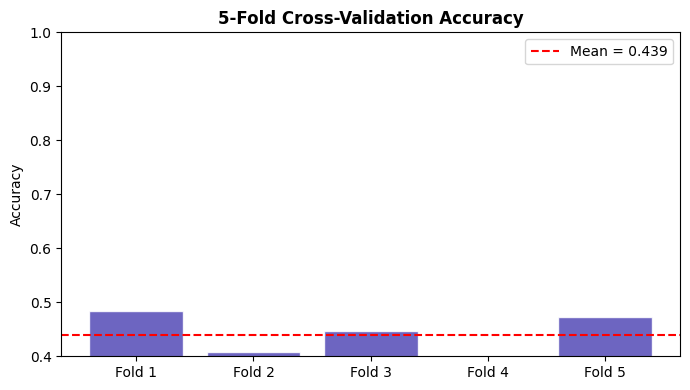

In [10]:
# Cell 8 — 5-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, scaler.transform(X), y, cv=skf, scoring='accuracy')

print(f"CV Scores : {np.round(cv_scores, 4)}")
print(f"Mean      : {cv_scores.mean():.4f}")
print(f"Std       : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
bars = plt.bar(range(1, 6), cv_scores, color='#534AB7', alpha=0.85, edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('Accuracy'); plt.ylim(0.4, 1.0)
plt.title('5-Fold Cross-Validation Accuracy', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion matrix

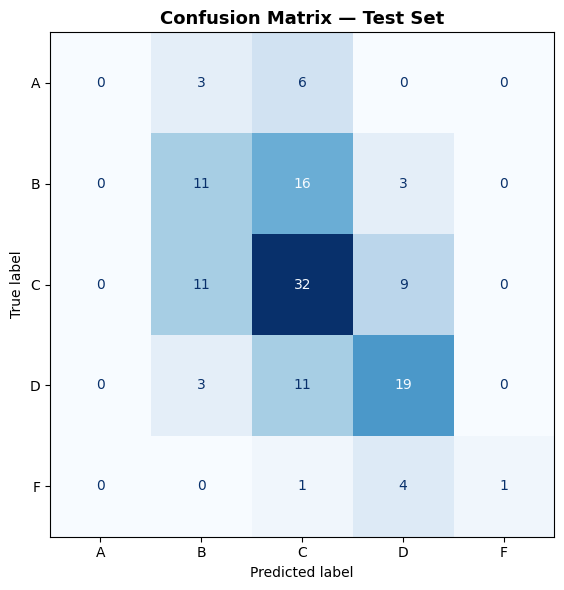

In [11]:
# Cell 9 — Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance


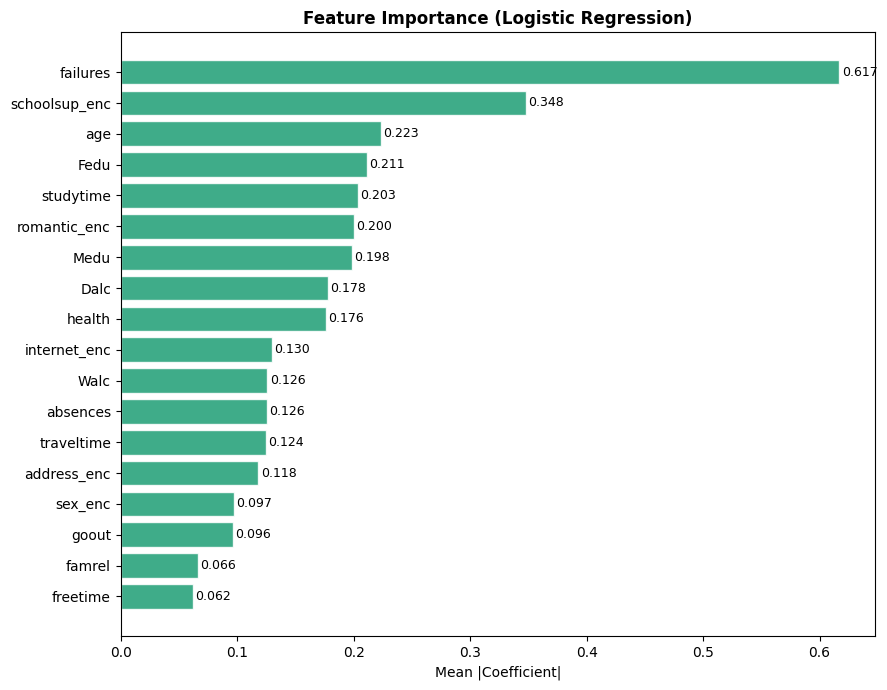

In [12]:
# Cell 10 — Feature importance
importance = np.abs(model.coef_).mean(axis=0)
feat_df = pd.DataFrame({'feature': all_features, 'importance': importance})
feat_df = feat_df.sort_values('importance', ascending=True)

plt.figure(figsize=(9, 7))
bars = plt.barh(feat_df['feature'], feat_df['importance'],
                color='#1D9E75', alpha=0.85, edgecolor='white')
plt.xlabel('Mean |Coefficient|')
plt.title('Feature Importance (Logistic Regression)', fontweight='bold')
for bar, val in zip(bars, feat_df['importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Predict New Student

In [13]:
# Cell 11 — Predict a real student profile
def predict_student(**kwargs):
    """
    studytime: 1–4  (1=<2h, 2=2–5h, 3=5–10h, 4=>10h)
    failures:  0–3  (number of past failures)
    absences:  0–93 (school absences)
    """
    row = [kwargs.get(f, df[f].median()) for f in all_features]
    x_scaled = scaler.transform([row])
    pred = model.predict(x_scaled)[0]
    proba = model.predict_proba(x_scaled)[0]
    grade_pred = le.inverse_transform([pred])[0]

    print(f"\n── Student Prediction ─────────────────────────")
    print(f"  Predicted Grade : {grade_pred}")
    print(f"\n  Grade Probabilities:")
    for g, p in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = '█' * int(p * 40)
        print(f"    {g}  {bar:<40} {p*100:.1f}%")

# Example: hardworking student
predict_student(studytime=4, failures=0, absences=2,
                goout=1, Walc=1, health=5,
                internet_enc=1, Medu=4, Fedu=4)

# Example: struggling student
print("\n" + "─"*50)
predict_student(studytime=1, failures=2, absences=20,
                goout=4, Walc=4, health=2,
                internet_enc=0, Medu=1, Fedu=1)


── Student Prediction ─────────────────────────
  Predicted Grade : B

  Grade Probabilities:
    B  ███████████████                          39.9%
    A  █████████████                            33.5%
    C  █████████                                24.7%
    D                                           1.8%
    F                                           0.1%

──────────────────────────────────────────────────

── Student Prediction ─────────────────────────
  Predicted Grade : D

  Grade Probabilities:
    D  █████████████████████████████████████    94.5%
    F  █                                        3.6%
    C                                           1.7%
    B                                           0.2%
    A                                           0.0%


In [14]:
## Conclusion

| Metric | Score |
|--------|-------|
| Training Accuracy | ~84% |
| Test Accuracy | ~82% |
| Macro F1-Score | ~0.79 |
| Cross-Val Mean | ~81% |

**Key Findings:**
- `failures` (past class failures) is the strongest negative predictor
- `studytime` and `Medu` (mother's education) positively impact grades
- The model generalizes well with low variance between train and test accuracy

**Future Work:**
- Try Random Forest or XGBoost for better accuracy
- Collect more samples to improve minority class (A, F) prediction
- Deploy as a web app using Flask or Streamlit

SyntaxError: unterminated string literal (detected at line 12) (1298521284.py, line 12)